# Data Preprocessing & Model Training Pipeline


In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# File path to the original raw dataset
DATA_PATH = r"data/AI purchase cost project (STUDENT DATA) V3.csv"

# Let's load the data
df = pd.read_csv(DATA_PATH, sep=";", decimal=",")
print(f"Dataset Loaded Successfully! Shape: {df.shape}")
df.head()





Dataset Loaded Successfully! Shape: (780760, 11)


,Shipment,LAADDATUM,Load code,Unload code,Payweight,Distribution driven by code,Price category,Crossdock,ADR,Express,Thermo
0,2261706,1-1-2023,217,535,647.5,19,C,Y,N,N,N
1,2272552,2-1-2023,9,302,700.0,18,B,Y,N,N,N
2,2272495,2-1-2023,66,1855,21000.0,76,E,N,N,N,N
3,2272650,2-1-2023,181,608,700.0,18,B,Y,N,N,N
4,2273247,2-1-2023,21,1010,2100.0,77,C,Y,N,N,N


## Step 1: Preprocessing Pipeline
We must convert dates, manage our high-cardinality discrete location codes (via Frequency Encoding to respect memory footprints), boolean cast string columns, and prepare a clean set of modelling features for our `Price category` classifications.


In [2]:
def preprocess_data(df):
    print("Starting preprocessing...")
    df_clean = df.copy()

    # 1. Drop Shipments
    if 'Shipment' in df_clean.columns:
        df_clean = df_clean.drop('Shipment', axis=1)

    # 2. Date parsing (LAADDATUM)
    df_clean['LAADDATUM'] = pd.to_datetime(df_clean['LAADDATUM'], format='%d/%m/%Y', errors='coerce')
    df_clean['Load_Year'] = df_clean['LAADDATUM'].dt.year
    df_clean['Load_Month'] = df_clean['LAADDATUM'].dt.month
    df_clean['Load_DayOfWeek'] = df_clean['LAADDATUM'].dt.dayofweek
    # We keep broader calendar patterns, but drop the day-of-month because
    # it showed almost no signal for the target and adds unnecessary noise.
    df_clean = df_clean.drop('LAADDATUM', axis=1)

    # 3. Y/N -> 1/0
    bool_cols = ['Crossdock', 'ADR', 'Express', 'Thermo']
    for col in bool_cols:
        df_clean[col] = df_clean[col].map({'Y': 1, 'N': 0}).fillna(0).astype('int8')



    # 5. Distance: stored as a European decimal string (comma as decimal separator).
    #    Convert to float and fill missing rows with the median so the model
    #    always receives a numeric value.
    if 'Distance' in df_clean.columns:
        df_clean['Distance'] = (
            df_clean['Distance']
            .astype(str)
            .str.replace(',', '.', regex=False)
            .replace('nan', float('nan'))
        )
        df_clean['Distance'] = pd.to_numeric(df_clean['Distance'], errors='coerce')
        distance_median = df_clean['Distance'].median()
        df_clean['Distance'] = df_clean['Distance'].fillna(distance_median)

    # 6. Handle High-Cardinality Variables (Frequency Encoding)
    high_card_cols = ['Load code', 'Unload code', 'Distribution driven by code']
    for col in high_card_cols:
        freq_encoding = df_clean[col].value_counts() / len(df_clean)
        df_clean[col + '_freq'] = df_clean[col].map(freq_encoding)
        df_clean = df_clean.drop(col, axis=1)

    return df_clean

df_processed = preprocess_data(df)
print(f"Data preprocessed! New Shape: {df_processed.shape}")
df_processed.head()


Starting preprocessing...
Data preprocessed! New Shape: (780760, 12)


,Payweight,Price category,Crossdock,ADR,Express,Thermo,Load_Year,Load_Month,Load_DayOfWeek,Load code_freq,Unload code_freq,Distribution driven by code_freq
0,647.5,C,1,0,0,0,2023,1,6,0.000004,0.006960,0.011648
1,700.0,B,1,0,0,0,2023,1,0,0.121087,0.001045,0.007516
2,21000.0,E,0,0,0,0,2023,1,0,0.022665,0.000088,0.000661
3,700.0,B,1,0,0,0,2023,1,0,0.003854,0.000220,0.007516
4,2100.0,C,1,0,0,0,2023,1,0,0.013203,0.000184,0.000211


## Step 2: Target Variable and Train-Test Split
Let's properly map and organize the target (`Price category`), then slice it into our Training and Testing sets.


In [3]:
# Encode target
le = LabelEncoder()
df_processed['Price category encoded'] = le.fit_transform(df_processed['Price category'].astype(str))

# Create mapping dictionary for future reference
price_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(f"Category Mapping (first 5 shown): {list(price_mapping.items())[:5]}")

# Define Features (X) and Target (y)
y = df_processed['Price category encoded']

# Drop target columns and features we do not want to use for modelling.
features_to_drop_before_modelling = ['Price category', 'Price category encoded', 'Load_Day']
X = df_processed.drop(columns=features_to_drop_before_modelling, errors='ignore')
print(f"Features removed before modelling: {features_to_drop_before_modelling}")

# Split data (80% Train, 20% validation)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")


Category Mapping (first 5 shown): [('B', np.int64(0)), ('C', np.int64(1)), ('D', np.int64(2)), ('E', np.int64(3)), ('F', np.int64(4))]
Features removed before modelling: ['Price category', 'Price category encoded', 'Load_Day']
Training features shape: (624608, 11)
Testing features shape: (156152, 11)


## Step 2.5: Exploratory Data Analysis Before Modeling

This section adds a compact exploratory analysis before training any model.

- The summary tables describe the structure and quality of the raw dataset.
- The price-category chart shows whether the target is balanced or dominated by a few categories.
- The feature heatmap shows how the processed input features relate to one another.
- The payweight chart checks whether one of the main numeric inputs changes visibly across price categories.

These checks are useful because they help explain model behaviour before any training starts.

In [4]:
from IPython.display import display
import matplotlib.pyplot as plt

# High-level dataset summary for documentation before modelling.
load_dates = pd.to_datetime(df['LAADDATUM'], format='%d-%m-%Y', errors='coerce')

dataset_overview = pd.DataFrame({
    'Metric': [
        'Rows',
        'Columns',
        'Date range start',
        'Date range end',
        'Missing cells',
        'Duplicate rows',
        'Unique price categories',
    ],
    'Value': [
        len(df),
        df.shape[1],
        load_dates.min().date(),
        load_dates.max().date(),
        int(df.isna().sum().sum()),
        int(df.duplicated().sum()),
        df['Price category'].nunique(),
    ]
})

feature_profile = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes.astype(str).values,
    'Missing Values': df.isna().sum().values,
    'Missing %': (df.isna().mean() * 100).round(2).values,
    'Unique Values': df.nunique().values,
})

print('Dataset overview:')
display(dataset_overview)

print('Feature profile:')
display(feature_profile.sort_values(['Missing Values', 'Unique Values'], ascending=[False, False]).reset_index(drop=True))

Dataset overview:


,Metric,Value
0,Rows,780760
1,Columns,11
2,Date range start,2023-01-01
3,Date range end,2025-12-31
4,Missing cells,0
5,Duplicate rows,0
6,Unique price categories,21


Feature profile:


,Column,Data Type,Missing Values,Missing %,Unique Values
0,Shipment,int64,0,0.0,780757
1,Payweight,float64,0,0.0,32582
2,Unload code,int64,0,0.0,10294
3,Distribution driven by code,int64,0,0.0,4568
4,Load code,int64,0,0.0,1599
5,LAADDATUM,str,0,0.0,1055
6,Price category,str,0,0.0,21
7,Crossdock,str,0,0.0,2
8,ADR,str,0,0.0,2
9,Express,str,0,0.0,2


### Price Category Frequency

This bar chart shows how often each target class appears in the full dataset.

- It is mainly a target-balance check.
- If a few classes dominate, accuracy can look strong even when minority classes are predicted poorly.
- This is important context for choosing evaluation metrics later, especially because the train/test split is stratified by class.

,Count,Share %
Price category,,
B,332257,42.56
C,158268,20.27
D,86972,11.14
E,49150,6.30
G,40997,5.25
I,29392,3.76
F,28199,3.61
H,25655,3.29
J,17116,2.19


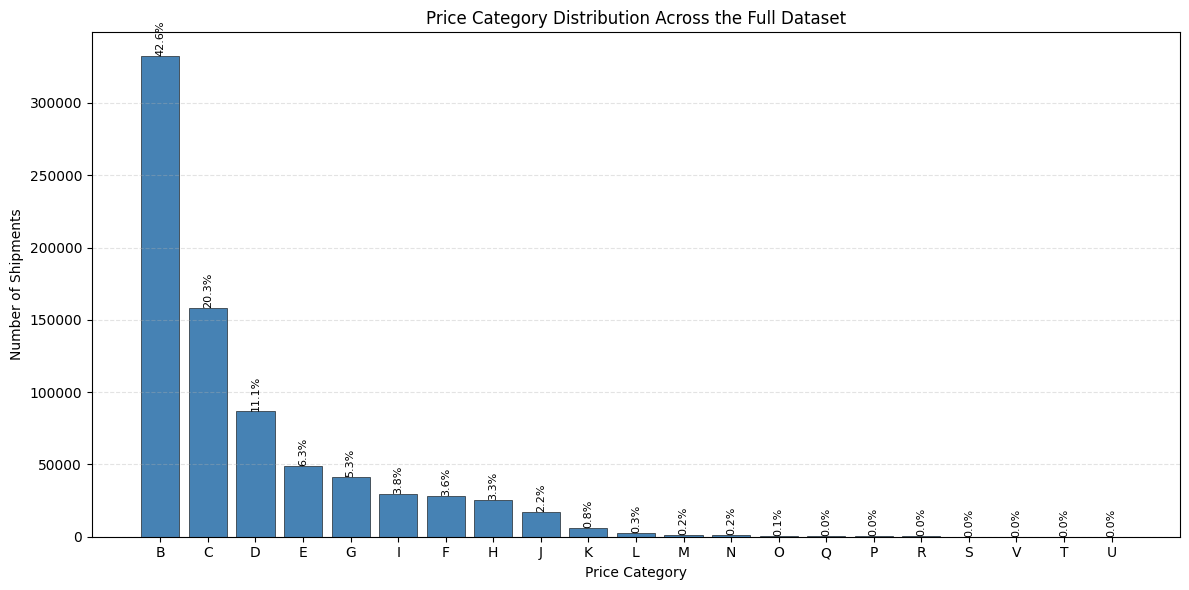

In [5]:
price_counts = df['Price category'].value_counts().sort_values(ascending=False)
price_percent = price_counts / price_counts.sum()

price_distribution = pd.DataFrame({
    'Count': price_counts,
    'Share %': (price_percent * 100).round(2),
})

display(price_distribution)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(price_counts.index.astype(str), price_counts.values, color='steelblue', edgecolor='black', linewidth=0.4)
ax.set_title('Price Category Distribution Across the Full Dataset')
ax.set_xlabel('Price Category')
ax.set_ylabel('Number of Shipments')
ax.grid(axis='y', linestyle='--', alpha=0.35)

for bar, pct in zip(bars, price_percent.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{pct:.1%}',
        ha='center',
        va='bottom',
        fontsize=8,
        rotation=90
    )

plt.tight_layout()
plt.show()

### Feature Correlation Heatmap

This heatmap shows the pairwise correlations between the processed model features.

- Positive values mean two features tend to increase together.
- Negative values mean one tends to rise when the other falls.
- Values close to zero suggest little linear relationship.

This is useful before modelling because very strong relationships can indicate overlapping information, while isolated features may contribute unique signal.

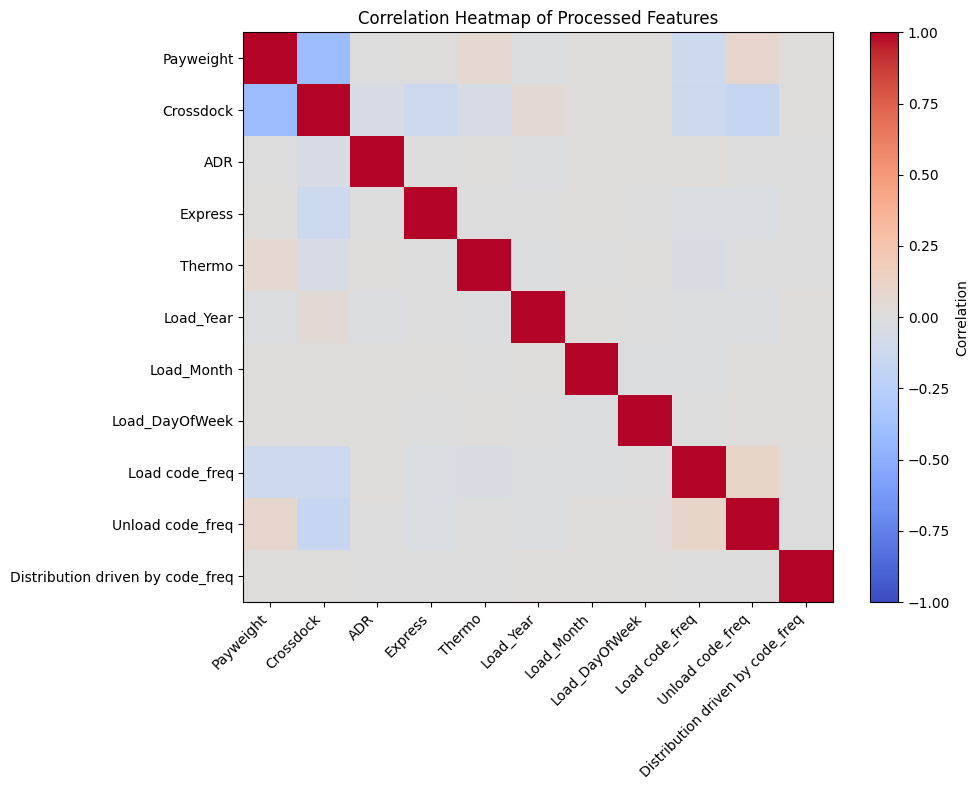

Strongest feature relationships:


,Feature 1,Feature 2,Correlation,Absolute Correlation
1,Payweight,Crossdock,-0.408,0.408
20,Crossdock,Unload code_freq,-0.151,0.151
19,Crossdock,Load code_freq,-0.120,0.120
14,Crossdock,Express,-0.119,0.119
8,Payweight,Load code_freq,-0.111,0.111
97,Load code_freq,Unload code_freq,0.096,0.096
9,Payweight,Unload code_freq,0.080,0.080
4,Payweight,Thermo,0.064,0.064
15,Crossdock,Thermo,-0.049,0.049
13,Crossdock,ADR,-0.048,0.048


In [6]:
corr_matrix = X.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))
heatmap = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr_matrix.index)))
ax.set_yticklabels(corr_matrix.index)
ax.set_title('Correlation Heatmap of Processed Features')

cbar = plt.colorbar(heatmap, ax=ax)
cbar.set_label('Correlation')

plt.tight_layout()
plt.show()

high_corr_pairs = (
    corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
high_corr_pairs.columns = ['Feature 1', 'Feature 2', 'Correlation']
high_corr_pairs['Absolute Correlation'] = high_corr_pairs['Correlation'].abs()
high_corr_pairs = high_corr_pairs.sort_values('Absolute Correlation', ascending=False)

print('Strongest feature relationships:')
display(high_corr_pairs.head(10).round(3))

## Feature Influence Checkpoint
Before training the model, this section measures how informative each feature is for predicting the target. It adds a ranked table, a visualization of the strongest signals, and compact summary tables to show how the most influential features vary across price categories.


### How to read the feature-influence graph
The horizontal bar chart ranks features by their **mutual information** with the target variable, `Price category`.

- Longer bars mean the feature provides more useful information for distinguishing price categories.
- Shorter bars mean the feature adds less signal on its own.
- This score shows **strength of relationship**, not whether the effect is positive or negative.
- The chart is best used as a ranking tool: focus first on the top features, then use the summary table below to see how those features change across categories.

After the graph, the first table shows the full ranking of all features, and the second table compares the top features across price categories using mean and median values.


Feature influence ranking (all features):


,Influence Rank,Feature,Mutual Information
0,1,Payweight,0.5746
1,2,Load code_freq,0.2414
2,3,Crossdock,0.1198
3,4,Unload code_freq,0.0543
4,5,Express,0.0153
5,6,Load_Year,0.0146
6,7,Load_DayOfWeek,0.0102
7,8,Load_Month,0.0048
8,9,Thermo,0.0035
9,10,ADR,0.0014


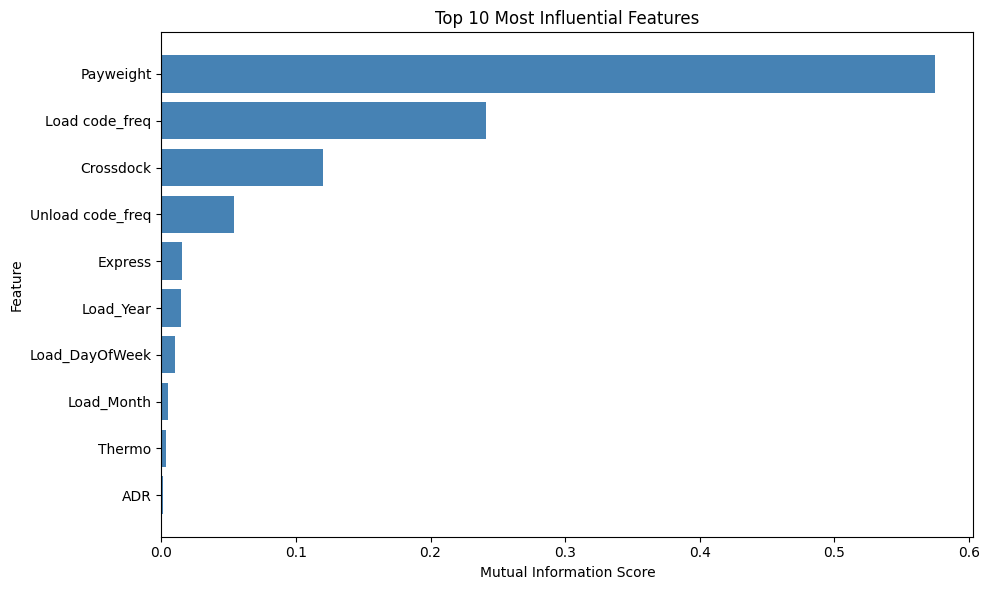

How the top features vary across price categories:


Payweight           Load code_freq        Crossdock         \
                     mean    median           mean median      mean median   
Price category                                                               
B                1000.798    700.00          0.049  0.030     0.630    1.0   
C                2040.361   1347.50          0.031  0.014     0.793    1.0   
D                6181.030   2625.00          0.029  0.014     0.585    1.0   
E                8319.294   4200.00          0.027  0.014     0.481    0.0   
F                8217.772   5250.00          0.027  0.013     0.432    0.0   
G               10020.730   7000.00          0.024  0.010     0.320    0.0   
H               14635.151  13000.00          0.027  0.014     0.190    0.0   
I               18189.181  21700.00          0.024  0.017     0.126    0.0   
J               20530.143  23100.00          0.023  0.014     0.063    0.0   
K               20350.270  23100.00          0.027  0.023     0.085    0.0   
L               19094.696  21875.00          0.041  0.023     0.111    0.0   
M               21615.916  23800.00          0.027  0.023     0.098    0.0   
N               20997.608  23800.00          0.038  0.035     0.056    0.0   
O               20068.255  22200.00          0.042  0.030     0.093    0.0   
P               20296.174  21411.25          0.061  0.035     0.151    0.0   
Q               22450.575  21682.50          0.081  0.121     0.014    0.0   
R               22331.470  22000.00          0.050  0.035     0.010    0.0   
S               22200.049  22000.00          0.027  0.000     0.000    0.0   
T               21311.399  21000.00          0.023  0.029     0.000    0.0   
U               21477.410  21000.00          0.025  0.029     0.000    0.0   
V               22015.123  21000.00          0.026  0.035     0.033    0.0   

               Unload code_freq        Express         
                           mean median    mean median  
Price category                                         
B                         0.002  0.001   0.000    0.0  
C                         0.001  0.001   0.001    0.0  
D                         0.001  0.001   0.007    0.0  
E                         0.001  0.001   0.009    0.0  
F                         0.001  0.000   0.035    0.0  
G                         0.001  0.000   0.081    0.0  
H                         0.001  0.000   0.038    0.0  
I                         0.001  0.000   0.041    0.0  
J                         0.001  0.000   0.047    0.0  
K                         0.001  0.000   0.057    0.0  
L                         0.001  0.000   0.167    0.0  
M                         0.001  0.000   0.066    0.0  
N                         0.000  0.000   0.060    0.0  
O                         0.000  0.000   0.091    0.0  
P                         0.001  0.000   0.074    0.0  
Q                         0.001  0.000   0.029    0.0  
R                         0.001  0.000   0.040    0.0  
S                         0.001  0.001   0.009    0.0  
T                         0.002  0.001   0.038    0.0  
U                         0.002  0.001   0.000    0.0  
V                         0.002  0.001   0.082    0.0

In [7]:
from IPython.display import display
from sklearn.feature_selection import mutual_info_classif
import matplotlib.pyplot as plt

# Estimate how much information each feature provides about the target.
mi_scores = mutual_info_classif(X_train, y_train, random_state=42)

feature_influence = (
    pd.DataFrame({
        'Feature': X_train.columns,
        'Mutual Information': mi_scores
    })
    .sort_values('Mutual Information', ascending=False)
    .reset_index(drop=True)
)
feature_influence['Influence Rank'] = feature_influence.index + 1
feature_influence = feature_influence[['Influence Rank', 'Feature', 'Mutual Information']]

print('Feature influence ranking (all features):')
display(feature_influence.style.format({'Mutual Information': '{:.4f}'}))

top_n = min(10, len(feature_influence))
top_features = feature_influence.head(top_n)

plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature'][::-1], top_features['Mutual Information'][::-1], color='steelblue')
plt.xlabel('Mutual Information Score')
plt.ylabel('Feature')
plt.title(f'Top {top_n} Most Influential Features')
plt.tight_layout()
plt.show()

# Show how the strongest features differ across target classes.
summary_features = feature_influence.head(min(5, len(feature_influence)))['Feature'].tolist()
feature_summary_by_category = (
    df_processed.groupby('Price category')[summary_features]
    .agg(['mean', 'median'])
    .round(3)
)

print('How the top features vary across price categories:')
display(feature_summary_by_category)


## Recommended Feature Selection Before Modeling
Based on the feature-influence analysis above, the first feature we should drop is `Load_Day`.

### Why `Load_Day` should be removed
- `Load_Day` represents the day of the month (1 to 31).
- In the influence ranking, it contributes almost no information for predicting `Price category`.
- Keeping a feature with almost no signal can add noise, make explanations harder, and slightly increase model complexity without improving results.
- Since we already keep stronger time-related features such as `Load_Month` and `Load_DayOfWeek`, dropping `Load_Day` simplifies the model without losing meaningful business information.

### Which other features could be considered for removal
- `Load_Year`: if almost all rows come from the same year, this feature will have very low variation and will not help the model learn much. It should only be kept if the dataset truly spans multiple years with meaningful pricing differences across years.
- Very low-influence binary flags such as `ADR`, `Thermo`, or `Express`: these should not be dropped automatically, because even a small effect can still matter operationally. They are better treated as **candidates for testing**, not immediate removals.

## Which Models Fit This Dataset Best
This is a **multiclass classification** problem with a large dataset, mostly tabular features, a mix of numeric variables, binary flags, and encoded categorical information. For this type of data, tree-based ensemble models are usually the strongest starting point.

### 1. Random Forest
Random Forest is a strong baseline because it handles non-linear relationships well, works nicely with mixed tabular features, and is easy to explain to a team.

Why it fits:
- It can capture interactions between variables such as `Payweight`, route-frequency features, and service flags.
- It does not require heavy feature scaling.
- It is usually robust when some features are weak or noisy.
- It also provides feature importance estimates that are easy to communicate.

Main limitation:
- On very large datasets, it can become slower and heavier than boosting models.

### 2. Gradient-Boosted Trees
If the group wants the best predictive performance, gradient-boosted tree models are often the strongest choice for structured business data.

Examples:
- XGBoost
- LightGBM
- CatBoost

Why they fit:
- They usually outperform simpler models on tabular datasets.
- They are very good at learning complex non-linear boundaries between price categories.
- They can work especially well when some features are much more informative than others.
- They often handle large datasets more efficiently than a large Random Forest.

Main limitation:
- They require more tuning

## Step 3: Setting Up Models (Trainer 1)
Here is where we will proceed with the first of our 3 Machine Learning models! A great baseline classifier for this task is a **Random Forest Classifier**.


In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize the first model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# TODO: Fit the model using rf_model.fit(X_train, y_train) 
# Note: This dataframe is extremely large (~600k rows) so training might take a minute!


## Step 3: Modeling Setup and Evaluation Helpers
Before training the models, we are going to set up a few helper functions so every model is judged in the same way. This is the part where we make the scoreboard fair: same train/test split, same metrics, same labels, no sneaky advantage for anyone wearing a prettier algorithm jacket.

We will track accuracy, macro F1, weighted F1, training time, prediction time, and a full classification report. Accuracy tells us the overall hit rate, macro F1 treats every price category equally, and weighted F1 gives more weight to categories that appear more often in the data. That combination matters because price categories can be imbalanced, and a model that only does well on the biggest class is basically taking the easiest seat in the group project.

In [9]:
from time import perf_counter
from sklearn.metrics import accuracy_score, classification_report, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

model_results = []
trained_models = {}

# Keep the original labels handy so reports are readable instead of looking like secret numeric codes.
target_names = [str(label) for label in le.classes_]


def evaluate_model(model_name, model, X_train, X_test, y_train, y_test):
    """Train a model, evaluate it, and store the results in a tidy table."""
    start_train = perf_counter()
    model.fit(X_train, y_train)
    train_seconds = perf_counter() - start_train

    start_predict = perf_counter()
    y_pred = model.predict(X_test)
    predict_seconds = perf_counter() - start_predict

    accuracy = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    weighted_f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    model_results.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Macro F1': macro_f1,
        'Weighted F1': weighted_f1,
        'Training time (sec)': train_seconds,
        'Prediction time (sec)': predict_seconds
    })
    trained_models[model_name] = model

    print(f'{model_name} finished training. The machine did not complain, which is always a good start.')
    print(f'Accuracy: {accuracy:.4f}')
    print(f'Macro F1: {macro_f1:.4f}')
    print(f'Weighted F1: {weighted_f1:.4f}')
    print(f'Training time: {train_seconds:.1f} seconds')
    print(f'Prediction time: {predict_seconds:.1f} seconds')
    print('\nClassification report:')
    print(classification_report(y_test, y_pred, target_names=target_names, zero_division=0))

    return y_pred

print('Evaluation helpers are ready.')
print(f'We are training on {X_train.shape[0]:,} rows and testing on {X_test.shape[0]:,} rows.')

Evaluation helpers are ready.
We are training on 624,608 rows and testing on 156,152 rows.


After this setup cell, we have a reusable evaluator. Nothing has been predicted yet; we have simply built the referee, the scoreboard, and the little clipboard where results will be stored.

The important part is that every model will now go through the same process. That makes the comparison cleaner, and it stops us from accidentally giving one model a nicer measuring tape than the other.

## Step 4: Random Forest Model
Now we train the Random Forest. A Random Forest is a collection of decision trees that vote together, like a committee where each tree has seen a slightly different version of the data. One tree on its own can be dramatic and overconfident; a forest usually calms things down by averaging many trees together.

We are using `class_weight='balanced_subsample'` because some price categories may appear more often than others. This tells the model to pay attention to smaller classes too, instead of acting like the biggest category is the main character of the entire notebook.

In [10]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=250,
    max_depth=None,
    min_samples_leaf=2,
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)

rf_predictions = evaluate_model(
    'Random Forest',
    rf_model,
    X_train,
    X_test,
    y_train,
    y_test
)

Random Forest finished training. The machine did not complain, which is always a good start.
Accuracy: 0.6216
Macro F1: 0.3976
Weighted F1: 0.6207
Training time: 41.6 seconds
Prediction time: 3.3 seconds

Classification report:
              precision    recall  f1-score   support

           B       0.85      0.84      0.85     66452
           C       0.54      0.55      0.55     31654
           D       0.45      0.43      0.44     17394
           E       0.35      0.32      0.33      9830
           F       0.28      0.21      0.24      5640
           G       0.38      0.47      0.42      8199
           H       0.39      0.37      0.38      5131
           I       0.50      0.56      0.53      5878
           J       0.45      0.50      0.48      3423
           K       0.38      0.38      0.38      1186
           L       0.40      0.30      0.34       488
           M       0.32      0.30      0.31       289
           N       0.37      0.47      0.41       254
           O   

The Random Forest output tells us how well the first model predicts the held-out test set. The overall accuracy is the quick headline number, but the F1 scores deserve attention because they show whether the model is handling all price categories reasonably or mostly leaning on the common ones.

The classification report gives precision, recall, and F1 for each category. If one row looks much weaker than the others, that category is where the model is having its awkward cafeteria moment: it is present, but it is not blending in confidently yet.

### Random Forest Confusion Matrix
Next we plot the confusion matrix for the Random Forest. This plot shows where the model is correct and where it gets confused. The diagonal cells are correct predictions; the off-diagonal cells are mistakes.

A good confusion matrix has most of its color on the diagonal. If we see heavy color away from the diagonal, that means the model is mixing up certain price categories. That is not a disaster; it is the model telling us exactly where it needs tutoring.

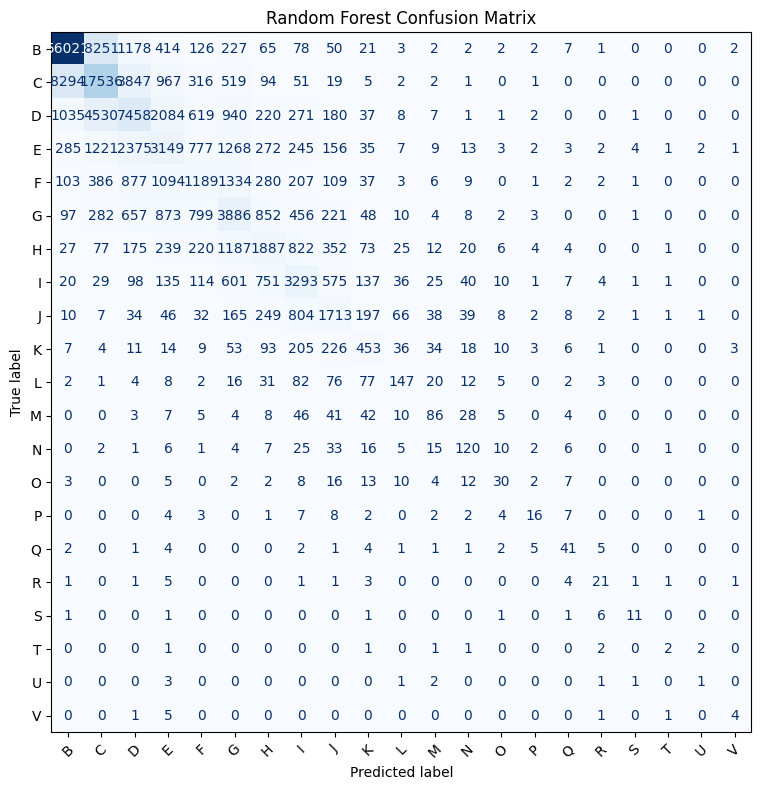

In [11]:
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_predictions,
    display_labels=target_names,
    xticks_rotation=45,
    cmap='Blues',
    ax=ax,
    colorbar=False
)
ax.set_title('Random Forest Confusion Matrix')
plt.tight_layout()
plt.show()

In this confusion matrix, the diagonal is where the Random Forest got the category right. The brighter that diagonal is compared with the rest of the chart, the happier we can be.

The off-diagonal blocks show the specific mix-ups. For example, if neighboring price categories are confused with each other, that is often understandable because their feature patterns may be genuinely similar. If far-apart categories are confused, then we should raise an eyebrow and investigate those rows more closely.

### Random Forest Feature Importance
Now we look at which features the Random Forest used the most. Feature importance does not prove causation, but it does show which columns helped the model split the data effectively.

This is useful for explaining the model to the group. Instead of saying, 'the forest has spoken,' we can point to actual variables and say which ones carried the prediction effort.

Top Random Forest feature importances:


,Feature,Importance
0,Unload code_freq,0.2085
1,Payweight,0.2038
2,Distribution driven by code_freq,0.1527
3,Load code_freq,0.1507
4,Load_Month,0.1149
5,Load_DayOfWeek,0.0789
6,Load_Year,0.0438
7,Crossdock,0.0158
8,ADR,0.0152
9,Express,0.0114


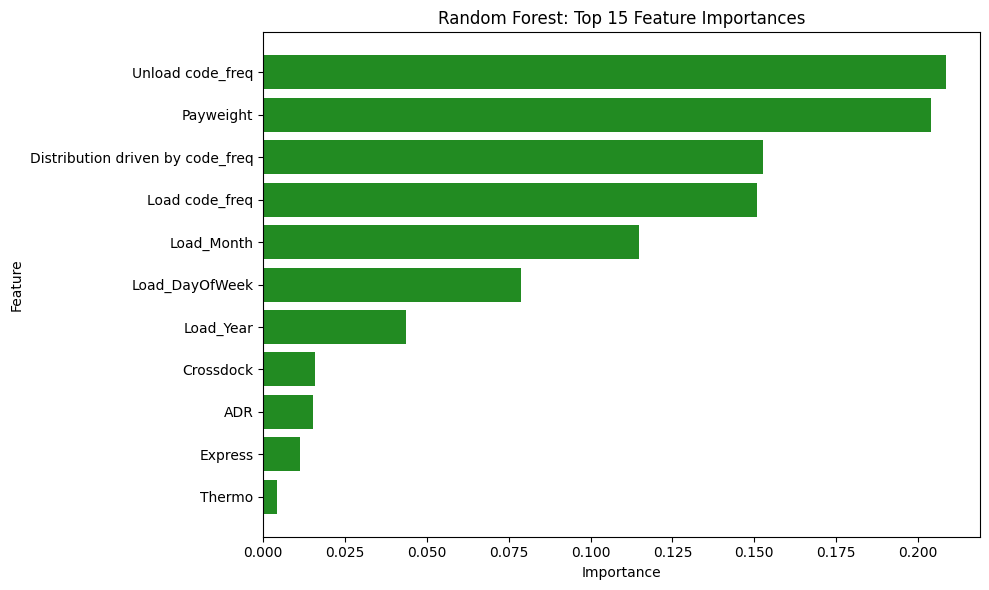

In [12]:
rf_importance = (
    pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': rf_model.feature_importances_
    })
    .sort_values('Importance', ascending=False)
    .reset_index(drop=True)
)

print('Top Random Forest feature importances:')
display(rf_importance.head(15).style.format({'Importance': '{:.4f}'}))

plt.figure(figsize=(10, 6))
plt.barh(
    rf_importance.head(15)['Feature'][::-1],
    rf_importance.head(15)['Importance'][::-1],
    color='forestgreen'
)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Random Forest: Top 15 Feature Importances')
plt.tight_layout()
plt.show()

This plot shows which features the Random Forest leaned on most heavily. Larger bars mean the feature helped the trees make useful splits more often.

If the top features match the earlier mutual-information checkpoint, that is a good sign: two different methods are pointing at similar signals. If they disagree, that is also interesting, because Random Forest importance can capture feature interactions that a one-feature-at-a-time influence check may miss. Models do enjoy being just mysterious enough to keep analysts employed.

## Step 5: Gradient-Boosted Tree Model
Now we train the boosted-tree model. We will try XGBoost first because it is usually one of the strongest choices for structured tabular data, especially when the goal is predictive performance. If XGBoost is not installed in the current environment, the notebook will automatically use scikit-learn's `HistGradientBoostingClassifier` instead.

Boosting works differently from Random Forest. Instead of building many independent trees and voting, boosted trees build trees sequentially, where each new tree tries to fix the mistakes made by the previous ones. It is basically the model version of saying, 'we can do better,' several hundred times in a row.

In [13]:
try:
    from xgboost import XGBClassifier

    boosted_model_name = 'XGBoost'
    boosted_model = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.08,
        subsample=0.9,
        colsample_bytree=0.9,
        objective='multi:softprob',
        eval_metric='mlogloss',
        tree_method='hist',
        random_state=42,
        n_jobs=-1
    )
except ImportError:
    from sklearn.ensemble import HistGradientBoostingClassifier

    boosted_model_name = 'HistGradientBoosting'
    boosted_model = HistGradientBoostingClassifier(
        max_iter=250,
        learning_rate=0.08,
        max_leaf_nodes=31,
        l2_regularization=0.1,
        early_stopping=True,
        random_state=42
    )

print(f'Using {boosted_model_name} for the gradient-boosted tree model.')

boosted_predictions = evaluate_model(
    boosted_model_name,
    boosted_model,
    X_train,
    X_test,
    y_train,
    y_test
)

Using HistGradientBoosting for the gradient-boosted tree model.


HistGradientBoosting finished training. The machine did not complain, which is always a good start.
Accuracy: 0.6310
Macro F1: 0.3527
Weighted F1: 0.6155
Training time: 77.8 seconds
Prediction time: 9.9 seconds

Classification report:
              precision    recall  f1-score   support

           B       0.81      0.90      0.85     66452
           C       0.53      0.53      0.53     31654
           D       0.44      0.43      0.43     17394
           E       0.40      0.23      0.29      9830
           F       0.47      0.12      0.19      5640
           G       0.38      0.54      0.45      8199
           H       0.45      0.30      0.36      5131
           I       0.49      0.60      0.54      5878
           J       0.52      0.46      0.49      3423
           K       0.43      0.30      0.35      1186
           L       0.41      0.25      0.31       488
           M       0.32      0.26      0.29       289
           N       0.40      0.37      0.39       254
        

The boosted-tree report gives us the second model's performance on the same held-out test set. This is the model we expect to be very competitive, because boosting is excellent at squeezing predictive signal out of tabular data.

If the boosted model beats Random Forest on weighted F1 and macro F1, it is probably the better production candidate. If it only wins accuracy but loses macro F1, then it may be improving the common categories while neglecting smaller ones, which is the statistical equivalent of doing all the easy chores first and hoping nobody checks the sink.

### Gradient-Boosted Tree Confusion Matrix
Now we plot the confusion matrix for the boosted-tree model. We want to compare the pattern of mistakes against the Random Forest, not just stare at one accuracy number and call it a personality test.

This helps us see whether both models struggle with the same categories or whether one model has a cleaner mistake pattern.

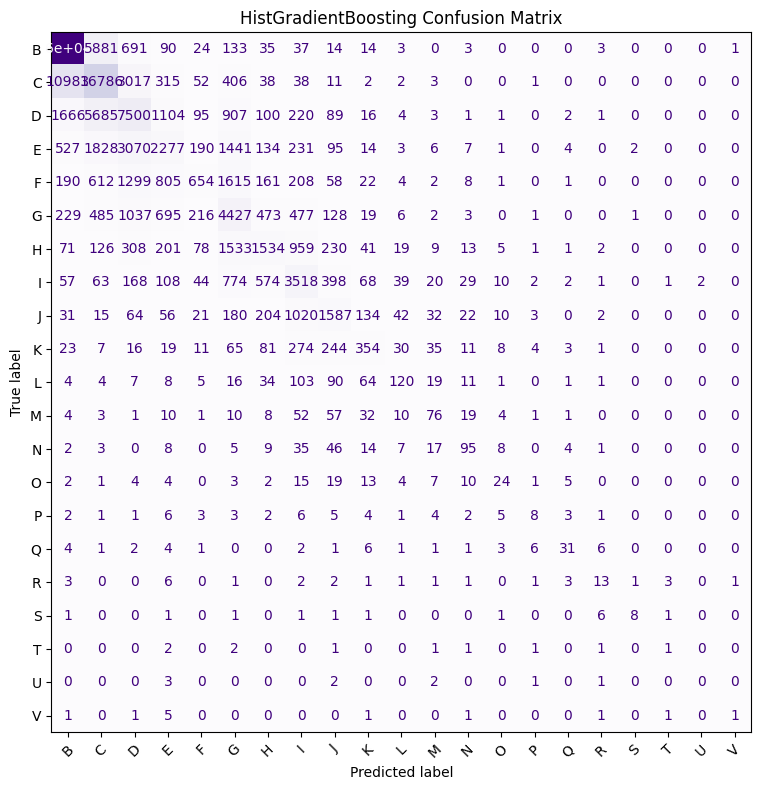

In [14]:
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    boosted_predictions,
    display_labels=target_names,
    xticks_rotation=45,
    cmap='Purples',
    ax=ax,
    colorbar=False
)
ax.set_title(f'{boosted_model_name} Confusion Matrix')
plt.tight_layout()
plt.show()

This confusion matrix shows the boosted model's correct and incorrect predictions. Again, the diagonal is the happy path, and the off-diagonal cells are where the model wandered into the wrong price category.

When we compare this plot with the Random Forest matrix, we can see whether boosting reduces the biggest mistakes or simply moves them around. A model that makes fewer mistakes in the categories that matter most to the business may be more useful even if the headline accuracy difference is small.

### Gradient-Boosted Tree Feature Importance
Finally, we inspect feature importance for the boosted-tree model. XGBoost gives built-in tree importances. If the notebook falls back to scikit-learn's histogram gradient boosting, we use permutation importance on a sample of the test set instead.

Permutation importance asks a useful question: what happens if we shuffle one feature and make it temporarily useless? If the score drops a lot, that feature was doing real work. It is a bit like hiding one teammate's notes and seeing whether the presentation suddenly gets worse.

Top HistGradientBoosting feature importances using permutation importance on a test-set sample:


,Feature,Importance
0,Payweight,0.3074
1,Load code_freq,0.1065
2,Unload code_freq,0.0588
3,Crossdock,0.0357
4,Load_Year,0.0116
5,Express,0.0080
6,ADR,0.0061
7,Load_Month,0.0048
8,Load_DayOfWeek,0.0035
9,Thermo,0.0027


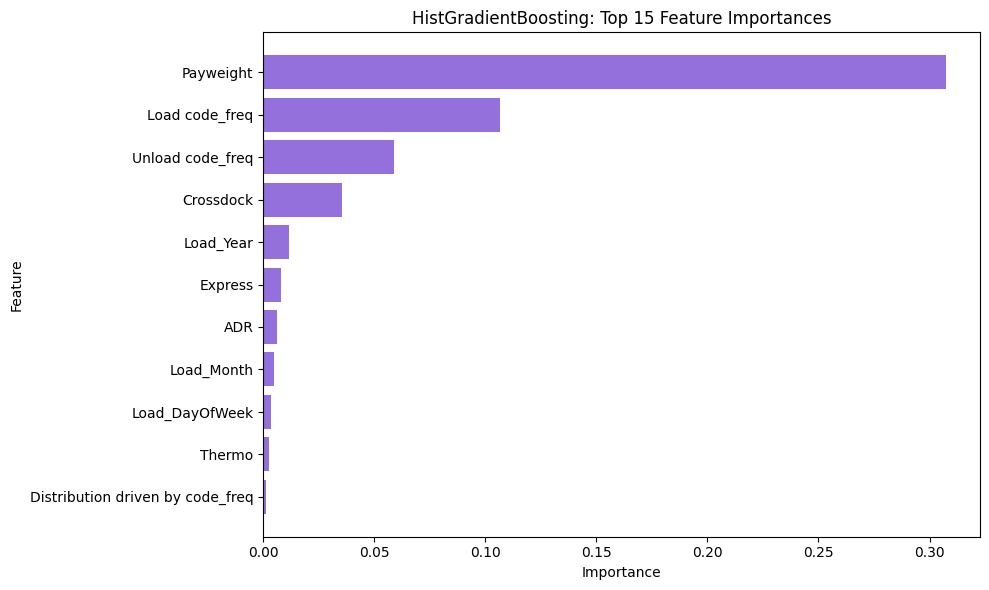

In [15]:
from sklearn.inspection import permutation_importance

boosted_importance_values = getattr(boosted_model, 'feature_importances_', None)
importance_source = 'built-in tree importance'

if boosted_importance_values is None:
    importance_source = 'permutation importance on a test-set sample'
    sample_size = min(20000, len(X_test))
    X_importance = X_test.sample(n=sample_size, random_state=42)
    y_importance = y_test.loc[X_importance.index]

    permutation_scores = permutation_importance(
        boosted_model,
        X_importance,
        y_importance,
        n_repeats=3,
        random_state=42,
        scoring='f1_weighted',
        n_jobs=-1
    )
    boosted_importance_values = permutation_scores.importances_mean

boosted_importance = (
    pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': boosted_importance_values
    })
    .sort_values('Importance', ascending=False)
    .reset_index(drop=True)
)

print(f'Top {boosted_model_name} feature importances using {importance_source}:')
display(boosted_importance.head(15).style.format({'Importance': '{:.4f}'}))

plt.figure(figsize=(10, 6))
plt.barh(
    boosted_importance.head(15)['Feature'][::-1],
    boosted_importance.head(15)['Importance'][::-1],
    color='mediumpurple'
)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title(f'{boosted_model_name}: Top 15 Feature Importances')
plt.tight_layout()
plt.show()

The boosted-tree importance plot shows which features were most useful to the boosted model. If this list resembles the Random Forest list, then both models are telling a consistent story about what drives price categories.

If the boosted model highlights different features, that does not automatically mean something is wrong. Boosting can use features in a more sequential, correction-focused way, so it may find useful patterns that Random Forest treats as less central. In group terms, the boosted model may be the one who noticed the weird detail on slide 17 that everyone else skipped.

## Step 6: Model Comparison and Final Choice
Now we put both models side by side. This is where we stop admiring individual reports and make a decision.

We will compare accuracy, macro F1, weighted F1, and runtime. The best model is not always the one with the highest single number; it should also be stable, explainable enough for the project, and reasonable to train again without requiring snacks, a charger, and emotional support.

In [16]:
results_df = (
    pd.DataFrame(model_results)
    .sort_values(['Weighted F1', 'Macro F1', 'Accuracy'], ascending=False)
    .reset_index(drop=True)
)

print('Model comparison:')
display(results_df.style.format({
    'Accuracy': '{:.4f}',
    'Macro F1': '{:.4f}',
    'Weighted F1': '{:.4f}',
    'Training time (sec)': '{:.1f}',
    'Prediction time (sec)': '{:.1f}'
}))

best_model_name = results_df.loc[0, 'Model']
best_model = trained_models[best_model_name]

print(f'Best model based on weighted F1, with macro F1 as the tie-breaker: {best_model_name}')

Model comparison:


,Model,Accuracy,Macro F1,Weighted F1,Training time (sec),Prediction time (sec)
0,Random Forest,0.6216,0.3976,0.6207,41.6,3.3
1,HistGradientBoosting,0.6310,0.3527,0.6155,77.8,9.9


Best model based on weighted F1, with macro F1 as the tie-breaker: Random Forest


The comparison table gives us the final scoreboard. Weighted F1 is used as the main ranking metric because it balances precision and recall while respecting how often each price category appears in the dataset. Macro F1 is kept close by because it tells us whether smaller categories are also being treated decently.

The selected best model is the one at the top of the table. If the boosted-tree model wins, we would recommend it for predictive performance. If Random Forest is close or better, then Random Forest becomes attractive because it is easier to explain and often less sensitive to tuning choices. Either way, we now have two trained models and a defensible comparison instead of just vibes in a spreadsheet trench coat.

## Modeling Summary
We trained two tree-based models for the multiclass `Price category` prediction task:

- **Random Forest**, our strong and explainable baseline.
- **Gradient-Boosted Trees**, using XGBoost when available and scikit-learn's histogram gradient boosting as the fallback.

We evaluated both models on the same test set using accuracy, macro F1, weighted F1, classification reports, confusion matrices, and feature-importance plots. This gives the group both performance numbers and interpretation material, which is helpful because a model with no explanation is just a confident black box wearing sunglasses indoors.